# 1. Libraries & Data Loading

We import the required libraries and load the dataset. We keep only the relevant message and label columns, then rename them for clarity.

In [3]:
# ===================================================
# 1. LIBRARIES & DATA LOADING
# ===================================================
import pandas as pd
import numpy as np

# Load dataset (latin-1 encoding handles special characters in text datasets)
df = pd.read_csv("spam.csv", encoding='latin-1')

# Keep only the first two main columns (label and message)
df = df.iloc[:, :2]

# Rename columns to simple, clear names
df.columns = ['label', 'message']

# Display first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 2. Data Cleaning & Encoding

We remove missing values and duplicates, then convert text labels ('ham' and 'spam') into numbers so our machine learning model can process them.

In [4]:
# ===================================================
# 2. DATA CLEANING & ENCODING
# ===================================================
# Remove missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()

# Convert labels to numbers: ham = 0, spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Check the count of ham vs spam messages
print("Label Counts:")
print(df['label'].value_counts())

# View updated dataset
df.head()

Label Counts:
label
ham     4516
spam     653
Name: count, dtype: int64


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


# 3. Train-Test Split & Feature Extraction

We split our dataset into training (80%) and testing (20%) sets. Then, we use TF-IDF Vectorizer to convert the raw text messages into numbers for machine learning.

In [5]:
# ===================================================
# 3. TRAIN-TEST SPLIT & FEATURE EXTRACTION
# ===================================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Define features (X) and target label (y)
X = df['message']
y = df['label_num']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text into numerical vectors using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training text samples:", X_train_vec.shape[0])
print("Testing text samples:", X_test_vec.shape[0])

Training text samples: 4135
Testing text samples: 1034


# 4. Model Training & Evaluation

We train a Naive Bayes model on our numerical text features and test its accuracy in predicting spam versus ham messages.

In [6]:
# ===================================================
# 4. MODEL TRAINING & EVALUATION
# ===================================================
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Train the Naive Bayes model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Make predictions on test data
y_pred = model.predict(X_test_vec)

# Check model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 96.62%

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.76      0.86       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



# 5. Visualizing Confusion Matrix & Custom Testing

We plot a confusion matrix to evaluate our predictions visually and test our trained model on new, custom email messages.

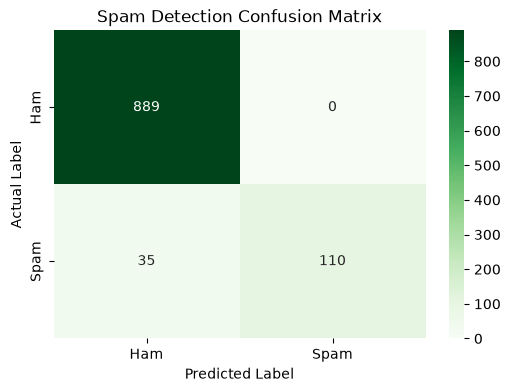

Message: 'Congratulations! You've won a $1,000 gift card. Click here to claim your prize now!' --> Prediction: Spam
Message: 'Hey, are we still meeting for lunch today at 1 PM?' --> Prediction: Ham (Legitimate)


In [10]:
# ===================================================
# 5. CONFUSION MATRIX & CUSTOM TESTING
# ===================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Spam Detection Confusion Matrix')
plt.show()

# Test custom messages
sample_messages = [
    "Congratulations! You've won a $1,000 gift card. Click here to claim your prize now!",
    "Hey, are we still meeting for lunch today at 1 PM?"
]

sample_vec = vectorizer.transform(sample_messages)
sample_preds = model.predict(sample_vec)

for msg, pred in zip(sample_messages, sample_preds):
    label = "Spam" if pred == 1 else "Ham (Legitimate)"
    print(f"Message: '{msg}' --> Prediction: {label}")